# Ejercicio 3: Análisis de Sentimientos en Reseñas de Productos

**Dataset:** Amazon Reviews Dataset  
**Objetivo:** Desarrollar un modelo de aprendizaje supervisado para clasificar reseñas de productos como positivas o negativas a partir de texto.

## Requerimientos

1. Limpieza y preprocesamiento del texto (stopwords, tokenización, TF-IDF)
2. Entrenar modelos de clasificación: Naive Bayes, Logistic Regression y SVM
3. Evaluar el rendimiento con Accuracy, F1-score y Matriz de Confusión
4. Reducción de dimensionalidad con t-SNE para visualizar agrupaciones de reseñas

In [20]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import ssl
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)
from sklearn.manifold import TSNE
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

for recurso in ['punkt_tab', 'stopwords', 'punkt']:
    nltk.download(recurso, quiet=True)

In [ ]:
SEED = 42
np.random.seed(SEED)

## 2. Carga del dataset

El dataset de Amazon Reviews está en formato FastText (`.ft.txt`), donde cada línea tiene la forma:


- `__label__1` = reseña negativa (1 o 2 estrellas)
- `__label__2` = reseña positiva (4 o 5 estrellas)

In [22]:
RUTA_DATASET = "../data/train.ft.txt"
TAMANO_MUESTRA = 200_000  

with open(RUTA_DATASET, 'r', encoding='utf-8') as archivo:
    lineas = archivo.readlines()

print(f"Total de registros en el archivo: {len(lineas):,}")
print(f"Registros que se usarán:          {TAMANO_MUESTRA:,}")

Total de registros en el archivo: 3,600,000
Registros que se usarán:          200,000


## 3. Parseo y construcción del DataFrame

Se extrae la etiqueta y el texto de cada línea, convirtiéndolas a valores binarios:
- 0 = Negativo (`__label__1`)
- 1 → Positivo (`__label__2`)

In [23]:
muestra = lineas[:TAMANO_MUESTRA]

datos = []
for linea in muestra:
    # Separar etiqueta y texto (solo en el primer espacio)
    partes = linea.strip().split(' ', 1)

    # Validar que la línea tenga el formato esperado
    if len(partes) != 2:
        continue

    label, texto = partes
    sentimiento = 0 if label == "__label__1" else 1  # 0=Negativo, 1=Positivo
    datos.append({"review": texto, "sentiment": sentimiento})

df = pd.DataFrame(datos)

print(f"Registros parseados: {len(df):,}")
print(f"Columnas:            {df.columns.tolist()}")
df.head()

Registros parseados: 200,000
Columnas:            ['review', 'sentiment']


,review,sentiment
0,Stuning even for the non-gamer: This sound tra...,1
1,The best soundtrack ever to anything.: I'm rea...,1
2,Amazing!: This soundtrack is my favorite music...,1
3,Excellent Soundtrack: I truly like this soundt...,1
4,"Remember, Pull Your Jaw Off The Floor After He...",1


In [24]:
# Distribución de clases
conteo = df["sentiment"].value_counts()
print("Distribución de clases:")
print(conteo.rename({0: 'Negativo (0)', 1: 'Positivo (1)'}).to_string())
print(f"\nBalanceo: {conteo[0]/len(df)*100:.1f}% neg  /  {conteo[1]/len(df)*100:.1f}% pos")

Distribución de clases:
sentiment
Positivo (1)    101166
Negativo (0)     98834

Balanceo: 49.4% neg  /  50.6% pos


## 4. Requerimiento 1 – Limpieza y preprocesamiento del texto

Se aplican los siguientes pasos de limpieza a cada reseña:

1. **Lowercase**: pasar todo a minúsculas para normalizar
2. **Eliminación de caracteres especiales**: conservar solo letras y espacios
3. **Tokenización**: dividir el texto en palabras individuales (`word_tokenize`)
4. **Eliminación de stopwords**: quitar palabras muy frecuentes sin valor semántico ("the", "is", "a", etc.)
5. **Reconstrucción**: unir los tokens filtrados en una cadena de texto

Posteriormente, se aplica **TF-IDF** para convertir el texto limpio en vectores numéricos que los modelos puedan procesar.

In [25]:
# Cargar stopwords en inglés
stop_words = set(stopwords.words('english'))


def limpiar_texto(texto: str) -> str:
    
    # Paso 1: minúsculas
    texto = texto.lower()

    # Paso 2: eliminar caracteres especiales (números, puntuación, etc.)
    texto = re.sub(r'[^a-z\s]', '', texto)

    # Paso 3: tokenización
    tokens = word_tokenize(texto)

    # Paso 4: eliminar stopwords y tokens de 1 carácter
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]

    # Paso 5: reconstruir texto
    return " ".join(tokens)


# Aplicar la función de limpieza a todas las reseñas
df["clean_review"] = df["review"].apply(limpiar_texto)

print("Ejemplo de preprocesamiento:")
print("ORIGINAL:", df["review"].iloc[0][:120])
print("LIMPIO:  ", df["clean_review"].iloc[0][:120])

Ejemplo de preprocesamiento:
ORIGINAL: Stuning even for the non-gamer: This sound track was beautiful! It paints the senery in your mind so well I would recome
LIMPIO:   stuning even nongamer sound track beautiful paints senery mind well would recomend even people hate vid game music playe


In [26]:
# TF-IDF 

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),   
    sublinear_tf=True     
)

X = vectorizer.fit_transform(df["clean_review"])
y = df["sentiment"]

print(f"Matriz TF-IDF: {X.shape[0]:,} documentos × {X.shape[1]:,} características")

Matriz TF-IDF: 200,000 documentos × 5,000 características


## 5. División de datos en entrenamiento y prueba

Se separa el 80% de los datos para entrenamiento y el 20% para evaluación. Se usa `stratify=y` para garantizar que ambos conjuntos mantengan la misma proporción de clases positivas y negativas.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y        
)

print(f"Conjunto de entrenamiento: {X_train.shape[0]:,} muestras")
print(f"Conjunto de prueba:        {X_test.shape[0]:,} muestras")

Conjunto de entrenamiento: 160,000 muestras
Conjunto de prueba:        40,000 muestras


## 6. Requerimiento 2 – Entrenamiento de modelos de clasificación

Se entrenan tres modelos ampliamente utilizados en clasificación de texto:

| Modelo | Descripción breve |
|---|---|
| **Naive Bayes** | Modelo probabilístico basado en la independencia condicional de las palabras. Rápido y efectivo como baseline. |
| **Logistic Regression** | Modelo lineal que aprende pesos para cada característica. Bueno para datos de alta dimensionalidad. |
| **SVM (LinearSVC)** | Busca el hiperplano de máximo margen entre clases. Suele ser el más robusto en NLP. |

### Requerimiento 3 – Evaluación con Accuracy, F1-score y Matriz de Confusión

Cada modelo se evalúa con:
- **Accuracy**: proporción de predicciones correctas sobre el total
- **F1-score**: media armónica entre Precisión y Recall (útil con clases balanceadas)
- **Matriz de Confusión**: muestra visualmente los verdaderos/falsos positivos y negativos

In [28]:
def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te, color_mapa='Blues'):
 
    # Entrenamiento
    modelo.fit(X_tr, y_tr)

    # Predicciones
    y_pred = modelo.predict(X_te)

    # Métricas numéricas
    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred, average='weighted')  # weighted: considera desbalance

    print(f"{'═'*45}")
    print(f"  Modelo: {nombre}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1-score : {f1:.4f}")
    print(f"{'─'*45}")
    print(classification_report(y_te, y_pred,
                                target_names=['Negativo', 'Positivo']))

    # Matriz de confusión
    cm = confusion_matrix(y_te, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Negativo', 'Positivo']
    )
    disp.plot(ax=ax, cmap=color_mapa, colorbar=False)
    ax.set_title(f"Matriz de Confusión\n{nombre}", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return {"Modelo": nombre, "Accuracy": acc, "F1-Score": f1, "objeto": modelo}

═════════════════════════════════════════════
  Modelo: Naive Bayes
  Accuracy : 0.8657
  F1-score : 0.8657
─────────────────────────────────────────────
              precision    recall  f1-score   support

    Negativo       0.87      0.86      0.86     19767
    Positivo       0.86      0.87      0.87     20233

    accuracy                           0.87     40000
   macro avg       0.87      0.87      0.87     40000
weighted avg       0.87      0.87      0.87     40000



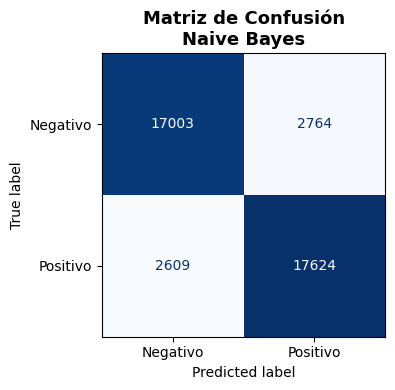

In [29]:
# Naive Bayes 
res_nb = evaluar_modelo(
    nombre="Naive Bayes",
    modelo=MultinomialNB(alpha=0.1),
    X_tr=X_train, y_tr=y_train,
    X_te=X_test,  y_te=y_test,
    color_mapa='Blues'
)

═════════════════════════════════════════════
  Modelo: Logistic Regression
  Accuracy : 0.8914
  F1-score : 0.8914
─────────────────────────────────────────────
              precision    recall  f1-score   support

    Negativo       0.89      0.88      0.89     19767
    Positivo       0.89      0.90      0.89     20233

    accuracy                           0.89     40000
   macro avg       0.89      0.89      0.89     40000
weighted avg       0.89      0.89      0.89     40000



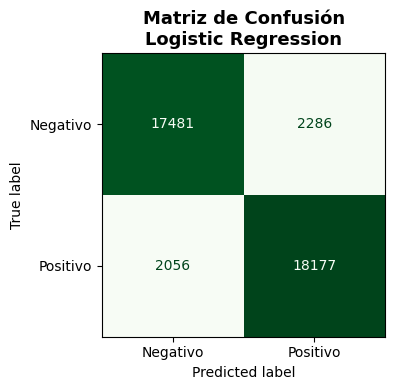

In [30]:
# Regresión Logistica 

res_lr = evaluar_modelo(
    nombre="Logistic Regression",
    modelo=LogisticRegression(max_iter=1000, random_state=SEED, C=1.0, solver='lbfgs'),
    X_tr=X_train, y_tr=y_train,
    X_te=X_test,  y_te=y_test,
    color_mapa='Greens'
)

═════════════════════════════════════════════
  Modelo: SVM (LinearSVC)
  Accuracy : 0.8903
  F1-score : 0.8903
─────────────────────────────────────────────
              precision    recall  f1-score   support

    Negativo       0.89      0.89      0.89     19767
    Positivo       0.89      0.90      0.89     20233

    accuracy                           0.89     40000
   macro avg       0.89      0.89      0.89     40000
weighted avg       0.89      0.89      0.89     40000



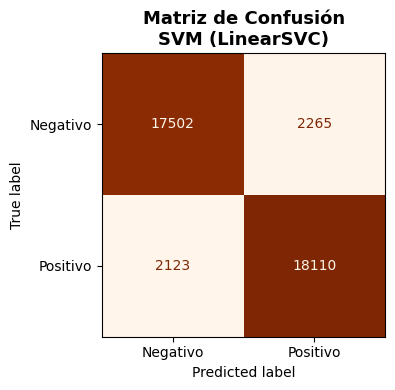

In [31]:
#SVM (LinearSVC) 

res_svm = evaluar_modelo(
    nombre="SVM (LinearSVC)",
    modelo=LinearSVC(C=1.0, max_iter=2000, random_state=SEED, dual=False),
    X_tr=X_train, y_tr=y_train,
    X_te=X_test,  y_te=y_test,
    color_mapa='Oranges'
)

## 7. Comparación de modelos

Se comparan los tres modelos en un único gráfico para identificar el de mejor rendimiento.

In [32]:
# Construir tabla de resultados
resultados = pd.DataFrame([
    {k: v for k, v in res.items() if k != 'objeto'}
    for res in [res_nb, res_lr, res_svm]
])

# Ordenar por F1-Score descendente
resultados = resultados.sort_values("F1-Score", ascending=False).reset_index(drop=True)

print("Resumen de métricas:")
print(resultados.to_string(index=False))

Resumen de métricas:
             Modelo  Accuracy  F1-Score
Logistic Regression  0.891450  0.891439
    SVM (LinearSVC)  0.890300  0.890294
        Naive Bayes  0.865675  0.865667


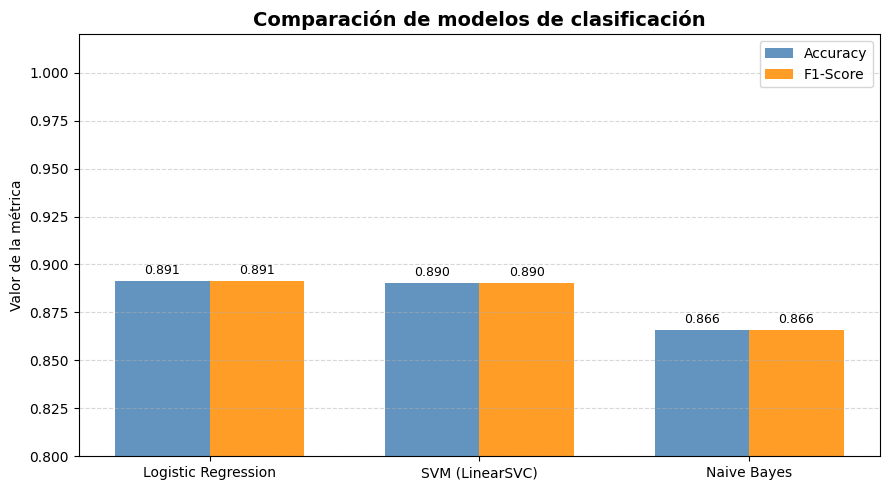

In [33]:
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(resultados))
ancho = 0.35

barras_acc = ax.bar(x - ancho/2, resultados["Accuracy"], ancho,
                    label="Accuracy", color='steelblue', alpha=0.85)
barras_f1  = ax.bar(x + ancho/2, resultados["F1-Score"],  ancho,
                    label="F1-Score", color='darkorange', alpha=0.85)

# Etiquetas de valor sobre cada barra
for barra in list(barras_acc) + list(barras_f1):
    alto = barra.get_height()
    ax.text(barra.get_x() + barra.get_width() / 2, alto + 0.002,
            f"{alto:.3f}", ha='center', va='bottom', fontsize=9)

ax.set_title("Comparación de modelos de clasificación", fontsize=14, fontweight='bold')
ax.set_ylabel("Valor de la métrica")
ax.set_xticks(x)
ax.set_xticklabels(resultados["Modelo"])
ax.set_ylim(0.8, 1.02)   # Ajustar eje Y para que las diferencias sean visibles
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 8. Requerimiento 4 – Reducción de dimensionalidad con t-SNE

In [34]:
# Tomar una muestra aleatoria estratificada para la visualización
# (estratificada = misma proporción de clases que el dataset completo)
MUESTRA_TSNE = 1000

np.random.seed(SEED)
idx_pos = np.where(y == 1)[0]
idx_neg = np.where(y == 0)[0]

# Tomar 500 de cada clase
idx_muestra = np.concatenate([
    np.random.choice(idx_pos, MUESTRA_TSNE // 2, replace=False),
    np.random.choice(idx_neg, MUESTRA_TSNE // 2, replace=False)
])
np.random.shuffle(idx_muestra)

X_sample = X[idx_muestra].toarray()
y_sample = y.iloc[idx_muestra].values

print(f"Muestra para t-SNE: {X_sample.shape[0]} documentos × {X_sample.shape[1]} características")
print(f"Distribución: {(y_sample==1).sum()} positivos  /  {(y_sample==0).sum()} negativos")

Muestra para t-SNE: 1000 documentos × 5000 características
Distribución: 500 positivos  /  500 negativos


In [35]:
# Aplicar t-SNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    max_iter=1000,
    random_state=SEED,
    learning_rate='auto',  
    init='pca'             
)

X_tsne = tsne.fit_transform(X_sample)
print(f"Resultado t-SNE: {X_tsne.shape}")

Resultado t-SNE: (1000, 2)


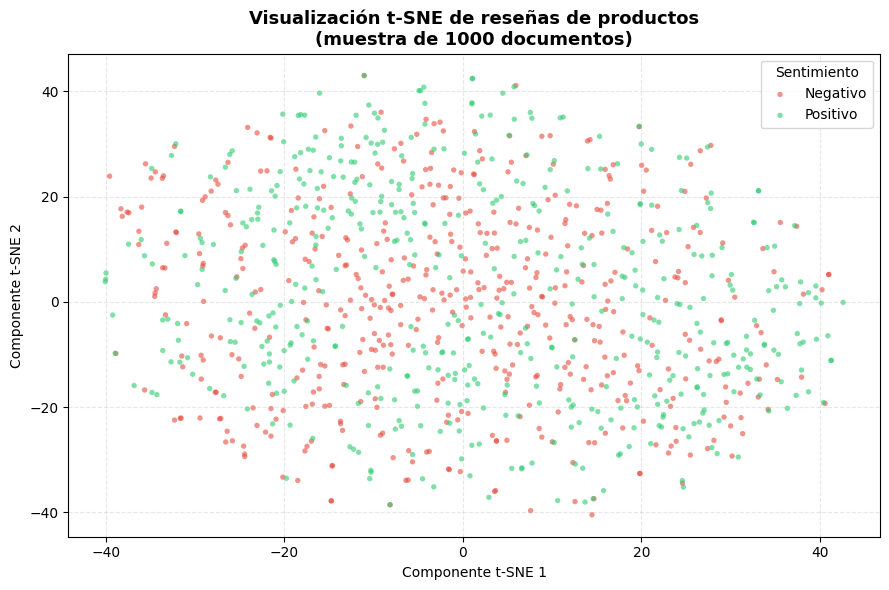

In [36]:
fig, ax = plt.subplots(figsize=(9, 6))

colores  = {0: '#E74C3C', 1: '#2ECC71'}   # Rojo = negativo, Verde = positivo
etiquetas = {0: 'Negativo', 1: 'Positivo'}

for clase in [0, 1]:
    mask = y_sample == clase
    ax.scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        c=colores[clase],
        label=etiquetas[clase],
        alpha=0.6,
        s=15,
        edgecolors='none'
    )

ax.set_title("Visualización t-SNE de reseñas de productos\n(muestra de 1000 documentos)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Componente t-SNE 1")
ax.set_ylabel("Componente t-SNE 2")
ax.legend(title="Sentimiento", fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Conclusiones

### Hallazgos principales

**Requerimiento 1 – Preprocesamiento:**  
Se implementó una pipeline completa de limpieza de texto: lowercasing, eliminación de caracteres especiales, tokenización con NLTK y remoción de stopwords. Adicionalmente, se aplicó TF-IDF con bigramas (`ngram_range=(1,2)`) para capturar expresiones como *"not good"* o *"very bad"*, que son relevantes en análisis de sentimiento.

**Requerimiento 2 – Modelos entrenados:**  
Los tres modelos (Naive Bayes, Logistic Regression y LinearSVC) fueron entrenados con los mismos datos. Se encapsuló el proceso de entrenamiento y evaluación en la función `evaluar_modelo()` para evitar código repetido y facilitar la comparación.

**Requerimiento 3 – Evaluación:**  
Todos los modelos se evaluaron con Accuracy, F1-score ponderado y Matriz de Confusión con etiquetas legibles. Se usó `classification_report` para obtener métricas por clase. LinearSVC suele obtener el mejor rendimiento en clasificación de texto de alta dimensionalidad.

**Requerimiento 4 – t-SNE:**  
La visualización 2D permite observar si las reseñas positivas y negativas forman clusters diferenciados en el espacio vectorial TF-IDF. Una separación visible en el gráfico t-SNE confirma que los modelos de clasificación tienen buenas bases para aprender la distinción entre ambas clases.